# 시나리오 롤링 파이프라인 — AR → CatBoost / TFT 3-way 비교

**목표**: AR 점예측을 기준으로 (1) **AR**, (2) **AR+CatBoost**(잔차 보정), (3) **AR+TFT**(Temporal Fusion Transformer, 잔차 보정) 세 가지의 12개월 예측 성능을 전체 5개의 롤링 윈도우에서 비교한다.

**TFT 변수 설계 (매우 중요)**
- 학습 단위(group)는 **Header 식별자(구·동·단지명·평형) + 롤링 원점**으로 잡아 매물별 잔차 궤적을 하나의 series로 구성한다.
- TFT의 **Variable Selection Network(VSN)** 가 나머지 feature(거시·지역 depth 수치, 정적 범주)들의 **상관성**을 학습하도록 변수를 배치한다.
  - `static_categoricals` = Header(구·동·단지명·평형) + Static 범주피처
  - `time_varying_known_reals` = h_step · base_drift · 원점추세 + 실현시점 거시/지역 depth 수치
  - `target` = `resid_target` (AR h스텝 로그오차) — CatBoost와 동일 잔차 타깃으로 공정 비교
- 캐시(`output/module0_cache`, `output/AR_vs_catboost`)를 재사용해 데이터 적재·잔차 학습세트 빌드를 가속한다.


In [21]:
# --- [Windows/인코딩 필수 설정 — 다른 import 보다 먼저] ---
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("PYTHONUTF8", "1")
os.environ.setdefault("PYTHONIOENCODING", "utf-8:replace")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

import re
import sys
import glob
import json
import time
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from catboost import CatBoostRegressor, Pool


def detect_catboost_task_type() -> str:
    """CatBoost GPU(CUDA) 가용 여부 자동 감지. CUDA GPU가 보이면 'GPU', 아니면 'CPU'."""
    try:
        from catboost.utils import get_gpu_device_count
        n = get_gpu_device_count()
        return "GPU" if n and n > 0 else "CPU"
    except Exception:
        return "CPU"


CATBOOST_TASK_TYPE = detect_catboost_task_type()
print(f"[env] python={sys.version.split()[0]}  numpy={np.__version__}  pandas={pd.__version__}")
print(f"[env] CatBoost task_type = {CATBOOST_TASK_TYPE}"
      + ("  (CUDA GPU 감지됨)" if CATBOOST_TASK_TYPE == "GPU" else "  (CUDA 없음 → CPU)"))


# ===== TFT / Lightning 추가 임포트 =====
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import RMSE as TFT_RMSE

TFT_ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
try:
    pl.seed_everything(42, workers=True)
except Exception:
    pass
print(f"[env] torch={torch.__version__}  CUDA={torch.cuda.is_available()}  TFT_ACCELERATOR={TFT_ACCELERATOR}")


Seed set to 42


[env] python=3.11.3  numpy=2.4.6  pandas=2.3.3
[env] CatBoost task_type = CPU  (CUDA 없음 → CPU)
[env] torch=2.4.1+cpu  CUDA=False  TFT_ACCELERATOR=cpu


## 설정 — GlobalConfig + AR 고정 + TFT 하이퍼파라미터

In [22]:
# 워크스페이스 루트 자동 탐지 (노트북 cwd가 ml_pipeline/final/ 이어도 동작)
def _find_workspace_root() -> str:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "meta_ml" / "output").exists():
            return str(cand)
    return str(p)


WORKSPACE_ROOT = _find_workspace_root()


@dataclass
class GlobalConfig:
    # ---- 경로 ----
    PANEL_ROOT: str = os.path.join(WORKSPACE_ROOT, "meta_ml", "output", "서울특별시")   # 전체 단지 패널 루트
    OUT_ROOT: str = os.path.join(WORKSPACE_ROOT, "ml_pipeline", "final", "output_final")  # 모든 단계 산출물 저장 루트
    CACHE_SRC: str = os.path.join(WORKSPACE_ROOT, "ml_pipeline", "final", "output", "module0_cache")  # 기존 패널 캐시 재사용원

    # ---- 롤링 윈도우 (예측창 시작월; 각 8년 학습 → 12개월 예측) ----
    # "뒷구간 96개월 학습" = 예측창 직전 8년을 학습구간으로.
    BT_STARTS: tuple = ("2024-06-01", "2023-06-01", "2022-06-01", "2021-06-01", "2020-06-01")
    TRAIN_YEARS: int = 8          # 96개월
    HORIZON: int = 12             # 예측 12개월(1년)

    # ---- 데이터 가드 ----
    MIN_TRAIN_MONTHS: int = 36    # 36개월 미만이면 시계열/계절성 추정 불안정 → 드롭

    # ---- 타깃 변환 ----
    LOG_TARGET: bool = True       # 로그공간: 이분산 완화 + 음수가격 차단

    # ---- AR (베이스라인 후보 & B* 점예측) ----
    AR_MAX_LAG: int = 12          # 월 데이터 → 1년 상한. 과대차수는 분산팽창
    AR_IC: str = "aic"            # 차수 선택: 'aic'(예측지향)
    SEASONAL_PERIOD: int = 24     # 월별 계절 주기

    # ---- CatBoost (전역 잔차 학습) — Phase 3 튜닝 결과 반영 ----
    CB_ITERATIONS: int = 3000     # [Phase3 튜닝확정] 부스팅 라운드(early stopping과 함께 상한). 작은 lr 보완
    CB_LEARNING_RATE: float = 0.03  # [Phase3 튜닝확정] + 많은 iter = 일반화 안정
    CB_DEPTH: int = 8             # 트리 깊이. 횡단면 상호작용 포착(6→8 상향)
    CB_L2_LEAF_REG: float = 3.0   # [Phase3 튜닝확정] 정규화(과적합 억제)
    CB_EARLY_STOP: int = 80       # 검증 손실 정체 라운드
    CB_RANDOM_SEED: int = 42
    CB_BORDER_COUNT: int = 254    # 수치 분할 경계 수(정밀도)
    CB_BAGGING_TEMPERATURE: float = 1.0  # 베이esian bagging 다양성
    CB_RANDOM_STRENGTH: float = 1.0      # 분할 점수 잡음(과적합 억제)
    PANEL_AR_MAX_LAG: int = 6     # 전역 패널 잔차 산출용 AR 최대차수
    ORIGIN_STRIDE: int = 12       # h스텝 오차 학습: 롤링 예측원점 간격(개월)
    INCLUDE_HSTEP_FEATURE: bool = True  # 예측지평 h를 피처로 추가
    AR_FORECAST_GUARD: float = 3.0   # AR 외삽 안정 가드(로그 ±3.0 초과 발산 원점 제외)
    ERR_CLIP_LOG: float = 1.0        # h스텝 로그오차 |e|>1.0(≈±172%) 이상치 제외

    # ---- BAR-X (Bayesian AR-X + Minnesota prior) ----
    BARX_MAX_LAG: int = 4
    MINNESOTA_LAMBDA: float = 0.2
    MINNESOTA_THETA: float = 0.5
    BARX_FREEZE_EXOG: bool = True

    # ---- 부트스트랩 (밴드 — 파이프라인 마지막) ----
    N_BOOTSTRAP: int = 1000
    BLOCK_SIZE: int = 3           # 블록 길이(개월) — 자기상관 보존
    QUANTILES: tuple = (0.1, 0.5, 0.9)
    BOOTSTRAP_SEED: int = 42
    PI_ALPHA: float = 0.2         # 80% 예측구간 → α=0.2 (Interval Score용)

    # ---- Fat-tail (Student-t 꼬리) + 이항 시나리오 자동산정 ----
    FAT_TAIL: bool = True
    T_DF_INIT: float = 5.0
    TAIL_PROB: float = 0.05
    EXTREME_QUANTILE: float = 0.98
    EXTREME_K_MIN: int = 30
    CONFIDENCE: float = 0.99
    HARD_FLOOR_N: int = 200

    # ---- 현실성 필터 ----
    REALISM_MAX_MOM: float = 0.25
    REALISM_DROP: bool = True

    # ---- SHAP ----
    SHAP_PER_GU: int = 500        # 구별 표집 수 → 25구 × 500 = 12,500 point

    # ---- 피처 선택 ----
    FEATURE_DROP_THRESHOLD: float = 0.005

    # ---- Phase 3 튜닝 목표 ----
    CATBOOST_WAPE_GAIN_TARGET: float = 0.10  # B*+CatBoost 가 B* 대비 평균 WAPE 10%↑ 우수

    # ---- 식별자(피처 아님) ----
    HEADER_COLS: tuple = ("Header_시", "Header_구", "Header_동", "Header_Timestamp", "Header_단지명", "Header_평형")
    TARGET_COL: str = "target"
    TIME_COL: str = "Header_Timestamp"


CFG = GlobalConfig()


def log_dir(name: str) -> str:
    """단계·모델명 폴더 생성 후 절대경로 반환 (중간결과 로그 저장용)."""
    d = os.path.join(CFG.OUT_ROOT, name)
    os.makedirs(d, exist_ok=True)
    return d


# 윈도우 객체 생성 (예측창 시작월 → 8년 학습 + 12개월 예측)
def _mk_window(bt_start: str, train_years: int = None, bt_months: int = None) -> dict:
    train_years = CFG.TRAIN_YEARS if train_years is None else train_years
    bt_months = CFG.HORIZON if bt_months is None else bt_months
    bs = pd.Timestamp(bt_start)
    w = {"name": f"BT@{bs:%Y-%m}",
         "tr_start": bs - pd.DateOffset(years=train_years),
         "tr_end":   bs - pd.DateOffset(months=1),
         "bt_start": bs,
         "bt_end":   bs + pd.DateOffset(months=bt_months - 1)}
    w["label"] = f"{w['tr_start']:%Y-%m}~{w['tr_end']:%Y-%m} → {w['bt_start']:%Y-%m}~{w['bt_end']:%Y-%m}"
    return w


BT_WINDOWS = [_mk_window(s) for s in CFG.BT_STARTS]
for i, _m in enumerate(["module0_cache", "baseline", "shap", "viz"]):
    log_dir(_m)

print("[cfg] 롤링 윈도우 (8년 학습 → 12개월 예측):")
for i, w in enumerate(BT_WINDOWS, 1):
    print(f"  BT{i}: {w['label']}")
print(f"[cfg] 산출물 루트: {CFG.OUT_ROOT}")
print(f"[cfg] CatBoost task_type: {CATBOOST_TASK_TYPE}")


# ===== AR 고정 + TFT 하이퍼파라미터 (이 노트북 전용) =====
B_STAR = "AR"                       # 이 노트북은 베이스라인을 AR로 고정 (AR → CatBoost / TFT 비교)
GROUP_KEYS = ["Header_구", "Header_동", "Header_단지명", "Header_평형"]

# TFT 설정 (CPU 학습 고려한 경량 기본값)
CFG.TFT_MAX_EPOCHS = 20
CFG.TFT_HIDDEN = 16
CFG.TFT_ATTN_HEADS = 2
CFG.TFT_DROPOUT = 0.1
CFG.TFT_HIDDEN_CONT = 8
CFG.TFT_LR = 0.02
CFG.TFT_BATCH = 128
CFG.TFT_MAX_TRAIN_SERIES = 1500     # CPU 속도 위해 윈도우당 학습 series 상한
CFG.TFT_EARLY_STOP = 4
CFG.TFT_SEED = 42

# 평가 대상 / 해석(SHAP·VSN) 설정
CFG.EVAL_MAX_GROUPS = None          # 백테스트 평가 대상 단지×평형 상한 (None=전체). 빠른 시험 시 정수 지정
CFG.SHAP_SAMPLE_ROWS = 20000        # CatBoost SHAP 계산 표본 행수(윈도우별)
CFG.VSN_SAMPLE_SERIES = 2000        # TFT VSN 해석 표본 series 수(윈도우별)

print(f"[cfg] B* 고정 = {B_STAR}  | TFT epochs={CFG.TFT_MAX_EPOCHS} hidden={CFG.TFT_HIDDEN} "
      f"max_series={CFG.TFT_MAX_TRAIN_SERIES}")


[cfg] 롤링 윈도우 (8년 학습 → 12개월 예측):
  BT1: 2016-06~2024-05 → 2024-06~2025-05
  BT2: 2015-06~2023-05 → 2023-06~2024-05
  BT3: 2014-06~2022-05 → 2022-06~2023-05
  BT4: 2013-06~2021-05 → 2021-06~2022-05
  BT5: 2012-06~2020-05 → 2020-06~2021-05
[cfg] 산출물 루트: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final
[cfg] CatBoost task_type: CPU
[cfg] B* 고정 = AR  | TFT epochs=20 hidden=16 max_series=1500


## depth 라벨 파싱 — 피처 그룹화

In [23]:
DEPTH_PATTERNS = {
    "D1_Macro":    re.compile(r"^depth1__"),
    "D2_Region":   re.compile(r"^depth2__"),
    "D3_RegionGu": re.compile(r"^depth3__"),
    "Static":      re.compile(r"^Static__"),
}


def group_columns(columns: List[str]) -> Dict[str, List[str]]:
    """컬럼명을 의미 그룹으로 분류. Header_/target 은 어디에도 넣지 않는다."""
    groups: Dict[str, List[str]] = {k: [] for k in DEPTH_PATTERNS}
    groups["Header"] = []; groups["Target"] = []
    for c in columns:
        if c == CFG.TARGET_COL:
            groups["Target"].append(c); continue
        if c.startswith("Header_"):
            groups["Header"].append(c); continue
        matched = False
        for g, pat in DEPTH_PATTERNS.items():
            if pat.match(c):
                groups[g].append(c); matched = True; break
        if not matched:
            groups.setdefault("Other", []).append(c)
    return groups


def feature_columns(columns: List[str]) -> Tuple[List[str], List[str]]:
    """CatBoost 입력용 (수치피처=D1+D2+D3, 범주피처=Static). Header/target 제외."""
    g = group_columns(columns)
    numeric = g["D1_Macro"] + g["D2_Region"] + g["D3_RegionGu"]
    categorical = g["Static"]
    return numeric, categorical


# Static 중 본래 수치형(역세권수·호재수)은 numeric으로 처리
STATIC_NUMERIC_HINT = {"Static__역세권수", "Static__호재수"}
print("[parse] depth 그룹 정규식 준비:", list(DEPTH_PATTERNS.keys()))


[parse] depth 그룹 정규식 준비: ['D1_Macro', 'D2_Region', 'D3_RegionGu', 'Static']


## 데이터 라우팅 — KB 선도 50 패널 + 전역 패널 (캐시 재사용)

In [24]:
# ===== 데이터 라우팅 — 보유 전체 아파트×평형 패널 (KB 선도 50 필터 제거) =====
# [요청 2] 선도 50단지가 아닌, 가지고 있는 전체 아파트+평형 데이터를 백테스트 대상으로 사용한다.
def load_all_panel(cutoff_end=None) -> pd.DataFrame:
    """meta_ml 전체 단지×평형 패널 적재. cutoff_end 지정 시 Header_Timestamp <= cutoff 만."""
    paths = glob.glob(os.path.join(CFG.PANEL_ROOT, "*", "*", "*.csv"))
    frames = []
    cutoff = pd.to_datetime(cutoff_end) if cutoff_end else None
    for p in paths:
        try:
            d = pd.read_csv(p, encoding="utf-8-sig")
        except Exception:
            continue
        if len(d) == 0 or CFG.TIME_COL not in d.columns or CFG.TARGET_COL not in d.columns:
            continue
        d[CFG.TIME_COL] = pd.to_datetime(d[CFG.TIME_COL])
        if cutoff is not None:
            d = d[d[CFG.TIME_COL] <= cutoff]
        if len(d):
            frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


_cache = log_dir("module0_cache")  # output_final/module0_cache
# 전체 패널(모든 아파트×평형, 전체 기간). 기존 output/module0_cache 캐시가 있으면 재사용.
_all_cache = os.path.join(_cache, "panel_all_full.pkl")
_legacy_full = os.path.join(CFG.CACHE_SRC, "global_panel_full.pkl")
if os.path.exists(_all_cache):
    panel_all = pd.read_pickle(_all_cache)
    print(f"[route] 전체 패널 캐시 로드: {panel_all.shape[0]:,}행")
elif os.path.exists(_legacy_full):
    panel_all = pd.read_pickle(_legacy_full)
    panel_all[CFG.TIME_COL] = pd.to_datetime(panel_all[CFG.TIME_COL])
    panel_all.to_pickle(_all_cache)
    print(f"[route] 기존 output 전체 패널 재사용 → output_final 캐시: {panel_all.shape[0]:,}행")
else:
    panel_all = load_all_panel(None)
    panel_all.to_pickle(_all_cache)
    print(f"[route] 전체 패널 적재·캐시: {panel_all.shape[0]:,}행")

_n_apt = panel_all[["Header_구", "Header_동", "Header_단지명"]].drop_duplicates().shape[0]
_n_pyeong = panel_all[GROUP_KEYS].drop_duplicates().shape[0]
print(f"[route] 전체: 단지 {_n_apt:,}개 · 단지×평형 {_n_pyeong:,}개 · "
      f"기간 {panel_all[CFG.TIME_COL].min().date()}~{panel_all[CFG.TIME_COL].max().date()}")
print(f"[route] 예상 분석 수 ≈ 단지×평형({_n_pyeong:,}) × {len(BT_WINDOWS)}윈도우 = "
      f"{_n_pyeong*len(BT_WINDOWS):,} (드롭 전)")

# 학습용 전역 패널 = 전체 패널에서 최대 tr_end 이하 (누수 차단)
_max_tr_end = max(w["tr_end"] for w in BT_WINDOWS)
panel_full = panel_all[panel_all[CFG.TIME_COL] <= _max_tr_end].reset_index(drop=True)
print(f"[route] 학습용 전역 패널(≤{_max_tr_end:%Y-%m}): {panel_full.shape[0]:,}행")


[route] 전체 패널 캐시 로드: 2,046,245행
[route] 전체: 단지 2,558개 · 단지×평형 11,302개 · 기간 2010-01-01~2026-05-01
[route] 예상 분석 수 ≈ 단지×평형(11,302) × 5윈도우 = 56,510 (드롭 전)
[route] 학습용 전역 패널(≤2024-05): 1,752,275행


## AR 베이스라인 · 지표 · 로그공간 변환

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

# ---- 점예측 지표 (원단위 만원) ----
def rmse(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def wape(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = np.sum(np.abs(y_true))
    return float(np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan


# ---- 로그공간 변환 ----
def to_model_space(y):
    y = np.asarray(y, float); return np.log(y) if CFG.LOG_TARGET else y


def to_price_space(z):
    z = np.asarray(z, float); return np.exp(z) if CFG.LOG_TARGET else z


def get_target_series(df: pd.DataFrame) -> pd.Series:
    return df.set_index(CFG.TIME_COL)[CFG.TARGET_COL].astype(float).sort_index()


# ---- 거시 외생(BAR-X 용) ----
EXOG_COLS = ["depth1__ecos__base_rate", "depth1__ecos__cd_91d_rate", "depth1__ecos__cpi_housing",
             "depth1__ecos__m2_avg", "depth1__ecos__mortgage_rate_new", "depth1__ecos__unemployment_rate"]


def get_exog_array(df: pd.DataFrame) -> np.ndarray:
    return (df.sort_values(CFG.TIME_COL)[EXOG_COLS]
            .apply(pd.to_numeric, errors="coerce").ffill().bfill().fillna(0.0).values)


# ---- AR 차수 선택 / 예측 ----
def fit_select_ar(train_z: np.ndarray, max_lag: int, ic: str):
    n = len(train_z); usable_max = min(max_lag, n // 3)
    best_p, best_ic, scores = 1, np.inf, {}
    for p in range(1, max(2, usable_max + 1)):
        try:
            res = AutoReg(train_z, lags=p, old_names=False).fit()
            val = res.aic if ic == "aic" else res.bic
            scores[p] = val
            if val < best_ic:
                best_ic, best_p = val, p
        except Exception:
            continue
    return best_p, scores


def forecast_ar(train_z, p, horizon):
    res = AutoReg(train_z, lags=p, old_names=False).fit()
    return np.asarray(res.predict(start=len(train_z), end=len(train_z) + horizon - 1), float)


def forecast_seasonal_naive(train_z, horizon, m):
    out = np.empty(horizon)
    for h in range(horizon):
        idx = len(train_z) - m + (h % m)
        out[h] = train_z[idx] if idx >= 0 else train_z[-1]
    return out


# ---- BAR / BAR-X : Bayesian AR(-X) + Minnesota prior (Theil mixed) ----
def _barx_design(z, Xex, p):
    n = len(z); rows = n - p; cols = 1 + p + Xex.shape[1]
    X = np.empty((rows, cols)); X[:, 0] = 1.0
    for i in range(1, p + 1):
        X[:, i] = z[p - i: n - i]
    X[:, 1 + p:] = Xex[p:]
    return X, z[p:]


def fit_barx_minnesota(z, Xex, p, lam, theta):
    X, y = _barx_design(z, Xex, p); k = X.shape[1]
    beta_ols, *_ = np.linalg.lstsq(X, y, rcond=None)
    sigma2 = float(np.mean((y - X @ beta_ols) ** 2)) or 1e-6
    m = np.zeros(k); m[1] = 1.0
    V = np.empty(k); V[0] = 1e6 * sigma2
    for i in range(1, p + 1):
        V[i] = (lam / i) ** 2
    if Xex.shape[1] > 0:
        sx = Xex[p:].std(axis=0); sx[sx == 0] = 1.0
        V[1 + p:] = (lam * theta) ** 2 * sigma2 / (sx ** 2)
    Dinv = np.diag(1.0 / V)
    A = X.T @ X + sigma2 * Dinv
    b = X.T @ y + sigma2 * (Dinv @ m)
    return np.linalg.solve(A, b), float(sigma2), y - X @ np.linalg.solve(A, b)


def forecast_barx(beta, z_hist, x_frozen, p, H):
    c = beta[0]; phi = beta[1:1 + p]; bx = beta[1 + p:]
    hist = list(z_hist[-p:])
    exog_term = float(bx @ x_frozen) if len(bx) else 0.0
    out = []
    for _ in range(H):
        zf = c + exog_term + sum(phi[i] * hist[-1 - i] for i in range(p))
        out.append(zf); hist.append(zf)
    return np.asarray(out, float)


BASELINE_MODELS = ["RandomWalk", "SeasonalNaive", "AR"]


def _guard_clip(fc, last):
    g = CFG.AR_FORECAST_GUARD
    return np.clip(np.asarray(fc, float), last - g, last + g)


def base_forecast_log(name, z_tr, horizon, exog_tr=None, p_ar=None):
    """단일 베이스라인의 horizon-스텝 로그 점예측(가드 클립)."""
    last = z_tr[-1]
    if name == "RandomWalk":
        return np.repeat(last, horizon)
    if name == "SeasonalNaive":
        return forecast_seasonal_naive(z_tr, horizon, CFG.SEASONAL_PERIOD)
    if name == "AR":
        p = min(p_ar if p_ar else 1, max(1, len(z_tr) // 3))
        try:
            return _guard_clip(forecast_ar(z_tr, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    if name in ("BAR", "BAR-X"):
        p = min(CFG.BARX_MAX_LAG, max(1, len(z_tr) // 3))
        if name == "BAR":
            Xex = np.zeros((len(z_tr), 0)); xf = np.zeros(0)
        else:
            Xex = exog_tr; xf = exog_tr[-1]
        try:
            beta, _, _ = fit_barx_minnesota(z_tr, Xex, p, CFG.MINNESOTA_LAMBDA, CFG.MINNESOTA_THETA)
            return _guard_clip(forecast_barx(beta, z_tr, xf, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    raise ValueError(f"unknown baseline: {name}")


print("[phase1] 지표/변환/베이스라인 3종 준비:", BASELINE_MODELS)


[phase1] 지표/변환/베이스라인 5종 준비: ['RandomWalk', 'SeasonalNaive', 'AR', 'BAR', 'BAR-X']


## Phase 1-B. 베이스라인 3종 평가 (RandomWalk · SeasonalNaive · AR)

`scenario_rolling_pipeline.ipynb` 와 동일하게, 보유 **전체 아파트×평형 × 5 롤링 윈도우**에서 생성된 **모든 시나리오**에 대해
세 가지를 함께 보고한다.
1. **평균 WAPE·RMSE** : 분석 케이스 전체 단순평균(평균적으로 얼마나 정확한가).
2. **우위 카운트** : 윈도우×단지·평형 조합별 승자(지표 최소)를 세어 합산(몇 번 이겼나).
3. **step별 거리 우위** : 모든 분석의 모든 step(월)에서 3종 중 실제값과 가장 가까운 모델을 카운트(어느 step에서 우위인가).


In [ ]:
# ===== Phase 1-B. 전체 아파트×평형 × 5 롤링 윈도우 베이스라인 3종 평가 =====
_BASE_DIR = log_dir("baseline")


def evaluate_baselines_windows(panel: pd.DataFrame, max_groups=None):
    """전체 단지×평형 × 5윈도우. 각 윈도우: 8년 train 적합 → H개월 단일원점 예측 → RMSE/WAPE.
    동시에 모든 step(월)에서 3종 중 실제값과 가장 가까운 모델(거리우위)을 카운트.
    반환: (long_df[윈도우·단지·모델·RMSE·WAPE], stepwise_wins{모델:점수}, total_steps, n_groups)."""
    rows = []
    stepwise_wins = {m: 0 for m in BASELINE_MODELS}
    total_steps = 0
    n_groups = 0
    BT = CFG.HORIZON
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        if max_groups is not None and n_groups >= max_groups:
            break
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL)
        t = g[CFG.TIME_COL]
        gid = "|".join(str(x) for x in keyvals)
        for w in BT_WINDOWS:
            tr = g[(t >= w["tr_start"]) & (t <= w["tr_end"])]
            bt = g[(t >= w["bt_start"]) & (t <= w["bt_end"])]
            ytr = tr[CFG.TARGET_COL].astype(float).values
            ybt = bt[CFG.TARGET_COL].astype(float).values
            if len(tr) < CFG.MIN_TRAIN_MONTHS or len(bt) < BT:
                continue
            if np.any(ytr <= 0) or np.any(ybt <= 0):
                continue
            z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
            exog_tr = get_exog_array(tr)
            y_true = ybt[:BT]
            try:
                p_star = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0]
            except Exception:
                p_star = 1
            preds = {}
            for m in BASELINE_MODELS:
                try:
                    zp = base_forecast_log(m, z_tr, BT, exog_tr=exog_tr, p_ar=p_star)
                except Exception:
                    continue
                yp = to_price_space(zp)
                preds[m] = yp
                rows.append({"윈도우": w["name"], "단지": gid, "모델": m,
                             "RMSE": rmse(y_true, yp), "WAPE": wape(y_true, yp)})
            # --- step별 거리 우위: 각 월에서 |실제-예측| 최소 모델 +1 ---
            if len(preds) == len(BASELINE_MODELS):
                dist = np.vstack([np.abs(y_true - preds[m]) for m in BASELINE_MODELS])  # (3, H)
                for wi in np.argmin(dist, axis=0):
                    stepwise_wins[BASELINE_MODELS[wi]] += 1
                total_steps += len(y_true)
    return pd.DataFrame(rows), stepwise_wins, total_steps, n_groups


def win_counts_keyed(df_long, metric, keys):
    wins = {}
    for _, gg in df_long.groupby(keys):
        w = gg.loc[gg[metric].idxmin(), "모델"]
        wins[w] = wins.get(w, 0) + 1
    return wins


base_df, stepwise_wins, total_steps, _ng = evaluate_baselines_windows(panel_all, CFG.EVAL_MAX_GROUPS)
base_df.to_csv(os.path.join(_BASE_DIR, "baseline_windows_all.csv"), index=False, encoding="utf-8-sig")
print(f"[phase1-B] {_ng:,}개 단지·평형 × {len(BT_WINDOWS)}윈도우 평가 완료 → {len(base_df):,}행")

# --- (1) 전체 평균 RMSE·WAPE ---
_finite = base_df.replace([np.inf, -np.inf], np.nan)
avg_table = _finite.groupby("모델")[["RMSE", "WAPE"]].mean().reindex(BASELINE_MODELS)
n_cases = base_df.groupby(["윈도우", "단지"]).ngroups
print(f"\n=== (1) 분석 케이스 전체 평균 RMSE·WAPE (총 {n_cases:,} 윈도우×단지·평형) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  평균RMSE {avg_table.loc[m,'RMSE']:>12,.1f}   평균WAPE {avg_table.loc[m,'WAPE']:>8.4f}")

# --- (2) 우위 카운트 (WAPE·RMSE; 윈도우×단지 조합별 승자) ---
wins_wape = win_counts_keyed(base_df, "WAPE", ["윈도우", "단지"])
wins_rmse = win_counts_keyed(base_df, "RMSE", ["윈도우", "단지"])
print(f"\n=== (2) 우위 카운트 (윈도우×단지·평형 조합별 승자, 총 {n_cases:,}) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  WAPE우위 {wins_wape.get(m,0):>6,} ({wins_wape.get(m,0)/max(n_cases,1):5.1%})   "
          f"RMSE우위 {wins_rmse.get(m,0):>6,} ({wins_rmse.get(m,0)/max(n_cases,1):5.1%})")

# --- (2-b) 윈도우별 WAPE 우위 카운트 ---
print(f"\n=== (2-b) 윈도우별 WAPE 우위 카운트 ===")
win_rows = []
for w in BT_WINDOWS:
    sub = base_df[base_df["윈도우"] == w["name"]]
    wc = win_counts_keyed(sub, "WAPE", ["단지"]) if len(sub) else {}
    row = {"윈도우": w["name"], **{m: wc.get(m, 0) for m in BASELINE_MODELS}}
    win_rows.append(row)
    print(f"  {w['name']}: " + " | ".join(f"{m} {wc.get(m,0):,}" for m in BASELINE_MODELS))
pd.DataFrame(win_rows).to_csv(os.path.join(_BASE_DIR, "baseline_win_counts_by_window.csv"),
                              index=False, encoding="utf-8-sig")

# --- (3) step별 거리 우위 ---
print(f"\n=== (3) step별 거리 우위 (모든 분석의 모든 월에서 실제값 최근접 모델, 총 {total_steps:,} step) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  {stepwise_wins.get(m,0):>8,} step ({stepwise_wins.get(m,0)/max(total_steps,1):5.1%})")

_best_wape = max(BASELINE_MODELS, key=lambda m: (wins_wape.get(m, 0), -avg_table.loc[m, "WAPE"]))
print(f"\n[phase1-B] WAPE 우위 최다 베이스라인 = {_best_wape}  (B*는 AR로 고정)")

# --- 로그/지표 저장 ---
avg_table.to_csv(os.path.join(_BASE_DIR, "baseline_avg_metrics.csv"), encoding="utf-8-sig")
pd.DataFrame({"모델": BASELINE_MODELS,
              "WAPE우위": [wins_wape.get(m, 0) for m in BASELINE_MODELS],
              "RMSE우위": [wins_rmse.get(m, 0) for m in BASELINE_MODELS],
              "step거리우위": [stepwise_wins.get(m, 0) for m in BASELINE_MODELS]}).to_csv(
    os.path.join(_BASE_DIR, "baseline_win_counts.csv"), index=False, encoding="utf-8-sig")

# --- 시각화 (① 평균 WAPE/RMSE · ② 우위 카운트 · ③ step 거리 우위) ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
xp = np.arange(len(BASELINE_MODELS))
axr = ax[0].twinx()
ax[0].bar(xp - 0.2, [avg_table.loc[m, "WAPE"] for m in BASELINE_MODELS], 0.4, color="tab:blue", label="WAPE")
axr.bar(xp + 0.2, [avg_table.loc[m, "RMSE"] for m in BASELINE_MODELS], 0.4, color="tab:orange", label="RMSE")
ax[0].set_xticks(xp); ax[0].set_xticklabels(BASELINE_MODELS, fontsize=8)
ax[0].set_ylabel("평균 WAPE"); axr.set_ylabel("평균 RMSE(만원)")
ax[0].set_title("① 평균 WAPE(파랑)·RMSE(주황)", fontsize=10)
ax[1].bar(xp - 0.2, [wins_wape.get(m, 0) for m in BASELINE_MODELS], 0.4, color="tab:blue", label="WAPE우위")
ax[1].bar(xp + 0.2, [wins_rmse.get(m, 0) for m in BASELINE_MODELS], 0.4, color="tab:green", label="RMSE우위")
ax[1].set_xticks(xp); ax[1].set_xticklabels(BASELINE_MODELS, fontsize=8)
ax[1].set_title(f"② 우위 카운트 (총 {n_cases:,})", fontsize=10); ax[1].legend(fontsize=8)
ax[2].bar(BASELINE_MODELS, [stepwise_wins.get(m, 0) for m in BASELINE_MODELS], color="tab:purple")
ax[2].set_title(f"③ step별 거리 우위 (총 {total_steps:,})", fontsize=10)
ax[2].tick_params(labelsize=8)
for r in ax[2].patches:
    ax[2].text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(r.get_height()):,}",
               ha="center", va="bottom", fontsize=7)
plt.suptitle(f"Phase 1-B: 베이스라인 3종 × {len(BT_WINDOWS)}윈도우 — 평균·우위·step거리", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(_BASE_DIR, "baseline_selection.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"[phase1-B] 저장: {_BASE_DIR}")


## 피처 정의 + h스텝 잔차 학습세트 빌더 + CatBoost

In [26]:
# ===== Phase 2-A. 피처 정의 + h스텝 오차 학습세트 빌더 =====
HSTEP_COL = "h_step"
ORIGIN_FEATS = ["base_drift", "origin_last", "origin_mom3", "origin_mom6", "origin_mom12"]


def split_features(columns: List[str]) -> Tuple[List[str], List[str]]:
    num, cat = feature_columns(columns)
    cat_final = [c for c in cat if c not in STATIC_NUMERIC_HINT]
    num_final = num + [c for c in cat if c in STATIC_NUMERIC_HINT]
    return num_final, cat_final


_num0, CAT_FEATS = split_features(list(panel_all.columns))
NUM_FEATS = _num0 + ([HSTEP_COL] if CFG.INCLUDE_HSTEP_FEATURE else []) + ORIGIN_FEATS
print(f"[feat] 수치피처 {len(NUM_FEATS)}개  | 범주피처 {len(CAT_FEATS)}개: {CAT_FEATS}")


def build_hstep_trainset(panel: pd.DataFrame, b_star: str) -> pd.DataFrame:
    """패널 각 단지×평형에서 롤링 원점 B* → h스텝 예측오차를 타깃으로. 피처=실현시점 거시/정적+h_step+원점추세."""
    out_frames = []
    n_groups = n_used = 0
    H = CFG.HORIZON
    for _, g in panel.groupby(GROUP_KEYS, sort=False):
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL).reset_index(drop=True)
        y = g[CFG.TARGET_COL].astype(float).values
        n = len(g)
        if n < CFG.MIN_TRAIN_MONTHS + 1 or np.any(y <= 0):
            continue
        z = np.log(y) if CFG.LOG_TARGET else y
        Xex_g = get_exog_array(g)
        p_c = fit_select_ar(z, CFG.PANEL_AR_MAX_LAG, CFG.AR_IC)[0] if b_star == "AR" else None
        used_this = False
        for t0 in range(CFG.MIN_TRAIN_MONTHS, n - 1, CFG.ORIGIN_STRIDE):
            z_tr = z[:t0]
            hmax = min(H, n - 1 - t0)
            if hmax < 1:
                continue
            try:
                fc = base_forecast_log(b_star, z_tr, hmax, exog_tr=Xex_g[:t0], p_ar=p_c)
            except Exception:
                continue
            fc = np.asarray(fc, float)
            if not np.all(np.isfinite(fc)):
                continue
            if np.max(np.abs(fc - z_tr[-1])) > CFG.AR_FORECAST_GUARD:
                continue
            idx_future = np.arange(t0, t0 + hmax)
            err = z[idx_future] - fc
            drift = fc - z_tr[-1]
            keep = np.abs(err) <= CFG.ERR_CLIP_LOG
            if not np.any(keep):
                continue
            idx_future, err, drift = idx_future[keep], err[keep], drift[keep]
            rows = g.iloc[idx_future].copy()
            rows[HSTEP_COL] = (idx_future - t0 + 1)
            rows["resid_target"] = err
            last = z_tr[-1]
            rows["base_drift"]   = drift
            rows["origin_last"]  = last
            rows["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
            rows["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
            rows["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
            out_frames.append(rows)
            used_this = True
        if used_this:
            n_used += 1
    res_df = pd.concat(out_frames, ignore_index=True) if out_frames else pd.DataFrame()
    print(f"    [resid] B*={b_star} | 그룹 {n_groups:,}개 중 {n_used:,}개 사용 → h스텝 오차샘플 {len(res_df):,}")
    return res_df


def _prep_features(df: pd.DataFrame) -> pd.DataFrame:
    """CatBoost 입력 정리: categorical=문자열+결측'NA', numeric=float."""
    X = df[NUM_FEATS + CAT_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = X[c].astype("object").where(X[c].notna(), "NA").astype(str)
    for c in NUM_FEATS:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


def make_catboost() -> CatBoostRegressor:
    """현재 CFG.CB_* 로 CatBoostRegressor 생성 (Phase 3 튜닝과 공유)."""
    return CatBoostRegressor(
        iterations=CFG.CB_ITERATIONS, learning_rate=CFG.CB_LEARNING_RATE, depth=CFG.CB_DEPTH,
        l2_leaf_reg=CFG.CB_L2_LEAF_REG, border_count=CFG.CB_BORDER_COUNT,
        bagging_temperature=CFG.CB_BAGGING_TEMPERATURE, random_strength=CFG.CB_RANDOM_STRENGTH,
        loss_function="RMSE", random_seed=CFG.CB_RANDOM_SEED, task_type=CATBOOST_TASK_TYPE,
        od_type="Iter", od_wait=CFG.CB_EARLY_STOP, verbose=False)


def train_catboost(ts: pd.DataFrame, verbose=False):
    """h스텝 학습세트 → 시간기반 hold-out(마지막 12개월) early stopping → (모델, X_va, y_va, mask)."""
    _cut = ts[CFG.TIME_COL].max() - pd.DateOffset(months=12)
    m = ts[CFG.TIME_COL] <= _cut
    Xtr = _prep_features(ts[m]);  ytr = ts.loc[m, "resid_target"].values
    Xva = _prep_features(ts[~m]); yva = ts.loc[~m, "resid_target"].values
    ci = [Xtr.columns.get_loc(c) for c in CAT_FEATS]
    cb = make_catboost()
    if verbose:
        cb.set_params(verbose=200)
    cb.fit(Pool(Xtr, ytr, cat_features=ci), eval_set=Pool(Xva, yva, cat_features=ci), use_best_model=True)
    return cb, Xva, yva, ~m


print("[phase2] 빌더 준비: build_hstep_trainset, _prep_features, make_catboost, train_catboost")


[feat] 수치피처 24개  | 범주피처 5개: ['Static__준공구분', 'Static__세대수구분', 'Static__평수구분', 'Static__건설사등급', 'Static__초품아여부']
[phase2] 빌더 준비: build_hstep_trainset, _prep_features, make_catboost, train_catboost


## Phase 3. 윈도우별 precompute (AR 점예측 + 피처)

In [27]:
# ===== Phase 3-A. precompute(AR 기준): 윈도우별 h스텝 학습세트 + 전체 아파트 AR 점예측·피처 =====
# 학습세트(누수차단)는 output_final/AR_vs_catboost 에 캐시(H 변경 시 자동 재빌드).
_bstar_tag = B_STAR.replace("-", "").replace("/", "")
_VS_DIR = log_dir(f"{_bstar_tag}_vs_catboost")
_TARGET, _TIME = CFG.TARGET_COL, CFG.TIME_COL


def build_window_trainset(tr_end):
    """tr_end 이하 전역 패널 → h스텝 학습세트(캐시). 누수 없음."""
    cache = os.path.join(_VS_DIR, f"hstep_trainset_{_bstar_tag}_{tr_end:%Y-%m}.pkl")
    if os.path.exists(cache):
        ts = pd.read_pickle(cache)
        print(f"    [resid] 캐시 로드 ≤{tr_end:%Y-%m}: {len(ts):,}행")
        return ts
    sub = panel_full[panel_full[_TIME] <= tr_end]
    ts = build_hstep_trainset(sub, B_STAR)
    ts.to_pickle(cache)
    return ts


def precompute_window(panel, w, max_groups=None):
    """전체 단지×평형: 윈도우 w의 AR 점예측 + CatBoost 입력 피처(Xprep) + TFT용 원본피처(feat_raw)."""
    H = CFG.HORIZON
    tr_lo, tr_hi = w["tr_start"], w["tr_end"]
    te_lo, te_hi = w["bt_start"], w["bt_end"]
    items = []
    n_seen = 0
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        if max_groups is not None and n_seen >= max_groups:
            break
        n_seen += 1
        g = g.sort_values(_TIME).reset_index(drop=True)
        t = g[_TIME]
        tr = g[(t >= tr_lo) & (t <= tr_hi)]
        te = g[(t >= te_lo) & (t <= te_hi)].head(H)
        ytr = tr[_TARGET].astype(float).values
        yte = te[_TARGET].astype(float).values
        if len(tr) < CFG.MIN_TRAIN_MONTHS or len(te) < H or np.any(ytr <= 0) or np.any(yte <= 0):
            continue
        z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
        last = z_tr[-1]
        exog_tr = get_exog_array(tr)
        try:
            p_c = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0] if B_STAR == "AR" else None
            base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)
        except Exception:
            continue
        if not np.all(np.isfinite(base_log)):
            continue
        feat = te.copy()
        feat[HSTEP_COL]      = np.arange(1, H + 1)
        feat["base_drift"]   = base_log - last
        feat["origin_last"]  = last
        feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
        feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
        feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
        items.append({
            "윈도우": w["name"], "단지": "|".join(str(x) for x in keyvals),
            "Xprep": _prep_features(feat), "feat_raw": feat.reset_index(drop=True),
            "base_log": base_log, "last": last,
            "yte": yte, "dates": pd.to_datetime(te[_TIME].values),
            "before_price": to_price_space(base_log),
        })
    return items


WIN_TRAINSETS = {}
WIN_ITEMS = {}
for w in BT_WINDOWS:
    print(f"[phase3-A] {w['name']}  {w['label']}")
    WIN_TRAINSETS[w["name"]] = build_window_trainset(w["tr_end"])
    WIN_ITEMS[w["name"]] = precompute_window(panel_all, w, max_groups=CFG.EVAL_MAX_GROUPS)
    print(f"    → 분석 케이스 {len(WIN_ITEMS[w['name']]):,}개")

_n_total = sum(len(v) for v in WIN_ITEMS.values())
before_wape = np.mean([wape(it["yte"], it["before_price"]) for v in WIN_ITEMS.values() for it in v])
before_rmse = np.mean([rmse(it["yte"], it["before_price"]) for v in WIN_ITEMS.values() for it in v])
print(f"\n[phase3-A] 분석 케이스 총 {_n_total:,}개  |  AR 평균 WAPE={before_wape:.4f}  RMSE={before_rmse:,.1f}")

# 베이스라인(AR) 윈도우별 지표 저장
_base_rows = [{"윈도우": w["name"], "분석수": len(WIN_ITEMS[w["name"]]),
               "AR_WAPE": np.mean([wape(it["yte"], it["before_price"]) for it in WIN_ITEMS[w["name"]]]) if WIN_ITEMS[w["name"]] else np.nan,
               "AR_RMSE": np.mean([rmse(it["yte"], it["before_price"]) for it in WIN_ITEMS[w["name"]]]) if WIN_ITEMS[w["name"]] else np.nan}
              for w in BT_WINDOWS]
pd.DataFrame(_base_rows).to_csv(os.path.join(log_dir("baseline"), "ar_baseline_by_window.csv"),
                                index=False, encoding="utf-8-sig")
print(f"[phase3-A] AR 베이스라인 지표 저장: {log_dir('baseline')}")


[phase3-A] BT@2024-06  2016-06~2024-05 → 2024-06~2025-05


KeyboardInterrupt: 

In [ ]:
# ===== Phase 3-B. 윈도우별 CatBoost 재학습(누수 차단) → AR / AR+CatBoost 점예측 =====
_CB_DIR = log_dir(f"{_bstar_tag}_catboost")
CB_BY_WINDOW = {}
for w in BT_WINDOWS:
    ts = WIN_TRAINSETS[w["name"]]
    cb_w, _, _, _ = train_catboost(ts, verbose=False)
    CB_BY_WINDOW[w["name"]] = cb_w
    cb_w.save_model(os.path.join(_CB_DIR, f"catboost_{_bstar_tag}_{w['name']}.cbm"))
    print(f"[phase3-B] {w['name']} CatBoost 재학습 best_iter={cb_w.get_best_iteration()} (학습 {len(ts):,}행)")

# 점예측: 윈도우별로 전체 아이템 Xprep 을 한 번에 배치 predict (속도)
for w in BT_WINDOWS:
    cb_w = CB_BY_WINDOW[w["name"]]
    items = WIN_ITEMS[w["name"]]
    if not items:
        continue
    big = pd.concat([it["Xprep"] for it in items], ignore_index=True)
    resid_hat = cb_w.predict(big)
    H = CFG.HORIZON
    for k, it in enumerate(items):
        rh = resid_hat[k * H:(k + 1) * H]
        it["pred_AR"] = it["before_price"]
        it["pred_ARCB"] = to_price_space(it["base_log"] + rh)
print(f"[phase3-B] AR · AR+CatBoost 점예측 저장 완료 · 모델 저장: {_CB_DIR}")


[phase3-B] BT@2024-06 CatBoost 재학습 best_iter=899 (학습 2,582,880행)
[phase3-B] BT@2023-06 CatBoost 재학습 best_iter=2967 (학습 2,314,152행)
[phase3-B] BT@2022-06 CatBoost 재학습 best_iter=1268 (학습 2,050,106행)
[phase3-B] AR · AR+CatBoost 점예측 저장 완료


## Phase 4. AR + TFT (Temporal Fusion Transformer) — Header 기준 그룹 학습

TFT는 AR의 h스텝 잔차(`resid_target`)를 예측한다(= CatBoost와 **동일 타깃**으로 공정 비교). 각 (Header 식별자, 롤링 원점) 궤적을 하나의 series로 구성하고, 윈도우별로 **별도 학습(누수 차단)** 한다. VSN(Variable Selection Network)이 거시·지역·정적 feature 간 **상관성**을 학습한다.


In [ ]:
# ===== Phase 4-A. TFT 변수 설정 + 데이터셋/학습/예측 빌더 =====
# [매우 중요] 학습은 "Header(구·동·단지명·평형) 식별자" 기준으로 그룹핑하고,
#  나머지 feature(거시·지역 depth 수치 + 정적 범주)들의 상관성을 TFT의
#  Variable Selection Network(VSN)가 학습하도록 변수를 배치한다.
#   - group_ids               : Header 식별자 + 롤링 원점 → 매물 단위 잔차 궤적(series)
#   - static_categoricals     : Header 구·동·단지명·평형 + Static 범주피처
#   - time_varying_known_reals: h_step · base_drift · 원점추세 + 실현시점 거시/지역 depth 수치
#   - target                  : resid_target (AR h스텝 로그오차)
MACRO_REALS = [c for c in NUM_FEATS if c != HSTEP_COL and c not in ORIGIN_FEATS]
TFT_STATIC_CAT = ["Header_구", "Header_동", "Header_단지명", "Header_평형"] + CAT_FEATS
TFT_KNOWN_REALS = [HSTEP_COL, "base_drift", "origin_last", "origin_mom3", "origin_mom6",
                   "origin_mom12"] + MACRO_REALS
print(f"[tft] group=Header+원점 | static_cat {len(TFT_STATIC_CAT)}개 | "
      f"known_reals {len(TFT_KNOWN_REALS)}개 (거시/지역 {len(MACRO_REALS)})")


def _coerce_tft(df):
    """TFT 입력 정리: 범주=문자열(결측 'NA'), 수치=float(결측 0), target=float."""
    for c in TFT_STATIC_CAT:
        df[c] = df[c].astype("object").where(df[c].notna(), "NA").astype(str)
    for c in TFT_KNOWN_REALS:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float).fillna(0.0)
    df["resid_target"] = pd.to_numeric(df["resid_target"], errors="coerce").astype(float).fillna(0.0)
    df["time_idx"] = df["time_idx"].astype(int)
    return df


def make_tft_train_df(ts):
    """h스텝 잔차 학습세트 → (Header|원점) series + 앵커행(time_idx=0, resid=0)."""
    d = ts.copy()
    d["h_step"] = d[HSTEP_COL].astype(int)
    realized = pd.to_datetime(d[CFG.TIME_COL]).dt.to_period("M")
    origin = (realized - d["h_step"]).astype(str)
    gid = d[GROUP_KEYS].astype(str).agg("|".join, axis=1)
    d["series_id"] = gid + "|" + origin
    d["time_idx"] = d["h_step"].astype(int)
    cols = ["series_id", "time_idx", "resid_target"] + TFT_STATIC_CAT + TFT_KNOWN_REALS
    base = d[cols].copy()
    anc = base.sort_values("time_idx").groupby("series_id", as_index=False).first()
    anc["time_idx"] = 0
    anc["resid_target"] = 0.0
    anc[HSTEP_COL] = 0.0
    anc["base_drift"] = 0.0
    out = pd.concat([anc, base], ignore_index=True)
    return _coerce_tft(out)


def make_tft_predict_df(items):
    """KB50 윈도우 아이템 → 예측용 series (time_idx 0..H, 길이 H+1)."""
    frames = []
    for it in items:
        f = it["feat_raw"].copy()
        f["h_step"] = f[HSTEP_COL].astype(int)
        f["time_idx"] = f["h_step"].astype(int)
        f["resid_target"] = 0.0
        f["series_id"] = it["단지"] + "@" + it["윈도우"]
        cols = ["series_id", "time_idx", "resid_target"] + TFT_STATIC_CAT + TFT_KNOWN_REALS
        base = f[cols].copy()
        anc = base.sort_values("time_idx").head(1).copy()
        anc["time_idx"] = 0
        anc["resid_target"] = 0.0
        anc[HSTEP_COL] = 0.0
        anc["base_drift"] = 0.0
        frames.append(pd.concat([anc, base], ignore_index=True))
    return _coerce_tft(pd.concat(frames, ignore_index=True))


def train_tft(ts, wname):
    """윈도우 잔차 학습세트로 TFT 1개 학습 (series 상한 샘플링 + 20% 검증 early stopping)."""
    df = make_tft_train_df(ts)
    sids = df["series_id"].unique()
    if len(sids) > CFG.TFT_MAX_TRAIN_SERIES:
        rng = np.random.default_rng(CFG.TFT_SEED)
        keep = set(rng.choice(sids, CFG.TFT_MAX_TRAIN_SERIES, replace=False))
        df = df[df["series_id"].isin(keep)].copy()
        sids = df["series_id"].unique()
    rng = np.random.default_rng(CFG.TFT_SEED + 1)
    val_ids = set(rng.choice(sids, max(1, int(0.2 * len(sids))), replace=False))
    tr_df = df[~df["series_id"].isin(val_ids)].copy()
    va_df = df[df["series_id"].isin(val_ids)].copy()
    cat_enc = {k: NaNLabelEncoder(add_nan=True) for k in ["series_id", *TFT_STATIC_CAT]}
    training = TimeSeriesDataSet(
        tr_df, time_idx="time_idx", target="resid_target", group_ids=["series_id"],
        max_encoder_length=1, min_encoder_length=1,
        max_prediction_length=CFG.HORIZON, min_prediction_length=1,
        static_categoricals=TFT_STATIC_CAT,
        time_varying_known_reals=TFT_KNOWN_REALS,
        time_varying_unknown_reals=["resid_target"],
        target_normalizer=GroupNormalizer(groups=[]),
        categorical_encoders=cat_enc,
        add_relative_time_idx=True, add_target_scales=True, allow_missing_timesteps=True)
    validation = TimeSeriesDataSet.from_dataset(training, va_df, predict=False, stop_randomization=True)
    tr_dl = training.to_dataloader(train=True, batch_size=CFG.TFT_BATCH, num_workers=0)
    va_dl = validation.to_dataloader(train=False, batch_size=CFG.TFT_BATCH, num_workers=0)
    model = TemporalFusionTransformer.from_dataset(
        training, hidden_size=CFG.TFT_HIDDEN, attention_head_size=CFG.TFT_ATTN_HEADS,
        dropout=CFG.TFT_DROPOUT, hidden_continuous_size=CFG.TFT_HIDDEN_CONT, output_size=1,
        loss=TFT_RMSE(), learning_rate=CFG.TFT_LR, log_interval=0, reduce_on_plateau_patience=3)
    trainer = pl.Trainer(
        max_epochs=CFG.TFT_MAX_EPOCHS, accelerator=TFT_ACCELERATOR, devices=1,
        enable_progress_bar=False, enable_checkpointing=False, logger=False,
        gradient_clip_val=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=CFG.TFT_EARLY_STOP)])
    trainer.fit(model, train_dataloaders=tr_dl, val_dataloaders=va_dl)
    print(f"[tft] {wname} 학습완료 series={len(sids):,} (val {len(val_ids):,})")
    return model, training


def predict_tft(model, training, items):
    """KB50 아이템들의 잔차 예측 → {series_id: resid_hat(H,)}."""
    pdf = make_tft_predict_df(items)
    pred_ds = TimeSeriesDataSet.from_dataset(training, pdf, predict=True, stop_randomization=True)
    pred_dl = pred_ds.to_dataloader(train=False, batch_size=256, num_workers=0)
    out = model.predict(pred_dl, mode="prediction", return_index=True)
    preds = np.asarray(out.output)
    idx = out.index.reset_index(drop=True)
    return {str(s): preds[i] for i, s in enumerate(idx["series_id"].astype(str))}


print("[phase4-A] 빌더 준비: make_tft_train_df, make_tft_predict_df, train_tft, predict_tft")


[tft] group=Header+원점 | static_cat 9개 | known_reals 24개 (거시/지역 18)
[phase4-A] 빌더 준비: make_tft_train_df, make_tft_predict_df, train_tft, predict_tft


In [ ]:
# ===== Phase 4-B. 윈도우별 TFT 학습(누수 차단) → AR+TFT 점예측 =====
_TFT_DIR = log_dir(f"{_bstar_tag}_tft")
TFT_BY_WINDOW = {}
H = CFG.HORIZON
for w in BT_WINDOWS:
    model, tds = train_tft(WIN_TRAINSETS[w["name"]], w["name"])
    TFT_BY_WINDOW[w["name"]] = (model, tds)
    torch.save(model.state_dict(), os.path.join(_TFT_DIR, f"tft_{_bstar_tag}_{w['name']}.pt"))
    sid2pred = predict_tft(model, tds, WIN_ITEMS[w["name"]])
    n_ok = 0
    for it in WIN_ITEMS[w["name"]]:
        sid = it["단지"] + "@" + it["윈도우"]
        rhat = sid2pred.get(sid)
        rhat = None if rhat is None else np.asarray(rhat, float).ravel()
        if rhat is None or rhat.size != H or not np.all(np.isfinite(rhat)):
            it["pred_ARTFT"] = it["pred_AR"]          # 예측 실패 시 AR로 폴백
        else:
            it["pred_ARTFT"] = to_price_space(it["base_log"] + rhat)
            n_ok += 1
    print(f"[phase4-B] {w['name']} AR+TFT 점예측 저장 ({n_ok:,}/{len(WIN_ITEMS[w['name']]):,}건 TFT 적용)")
print(f"[phase4-B] TFT 모델 저장: {_TFT_DIR}")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 23.7 K | train
3  | prescalers                         | ModuleDict                      | 448    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 3.0 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 18.6 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 17.9 K | train
7  | static_context_variable_selection  | GatedResidualNetwork 

[tft] BT@2024-06 학습완료 series=1,500 (val 300)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4-B] BT@2024-06 AR+TFT 점예측 저장 (346/346건 TFT 적용)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 23.4 K | train
3  | prescalers                         | ModuleDict                      | 448    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 3.0 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 18.6 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 17.9 K | train
7  | static_context_variable_selection  | GatedResidualNetwork 

...

[phase4-B] BT@2023-06 AR+TFT 점예측 저장 (334/334건 TFT 적용)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 23.8 K | train
3  | prescalers                         | ModuleDict                      | 448    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 3.0 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 18.6 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 17.9 K | train
7  | static_context_variable_selection  | GatedResidualNetwork 

[tft] BT@2022-06 학습완료 series=1,500 (val 300)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4-B] BT@2022-06 AR+TFT 점예측 저장 (320/320건 TFT 적용)


## Phase 5. AR vs AR+CatBoost vs AR+TFT — 3-way 성능 평가

① 3-way 평균 점예측 지표
         모델  평균WAPE      평균RMSE
         AR  0.1399 60,982.5550
AR+CatBoost  0.1246 49,377.9104
     AR+TFT  0.1300 47,039.4732

② 분석 단위 우위 카운트 (총 1,000개, 3종 중 최저)
         모델  WAPE우위  RMSE우위
         AR     291     259
AR+CatBoost     316     325
     AR+TFT     393     416

③ step별 거리 우위 (총 24,000 step)
         모델  step거리우위    비율
         AR      9108 0.380
AR+CatBoost      6910 0.288
     AR+TFT      7982 0.333


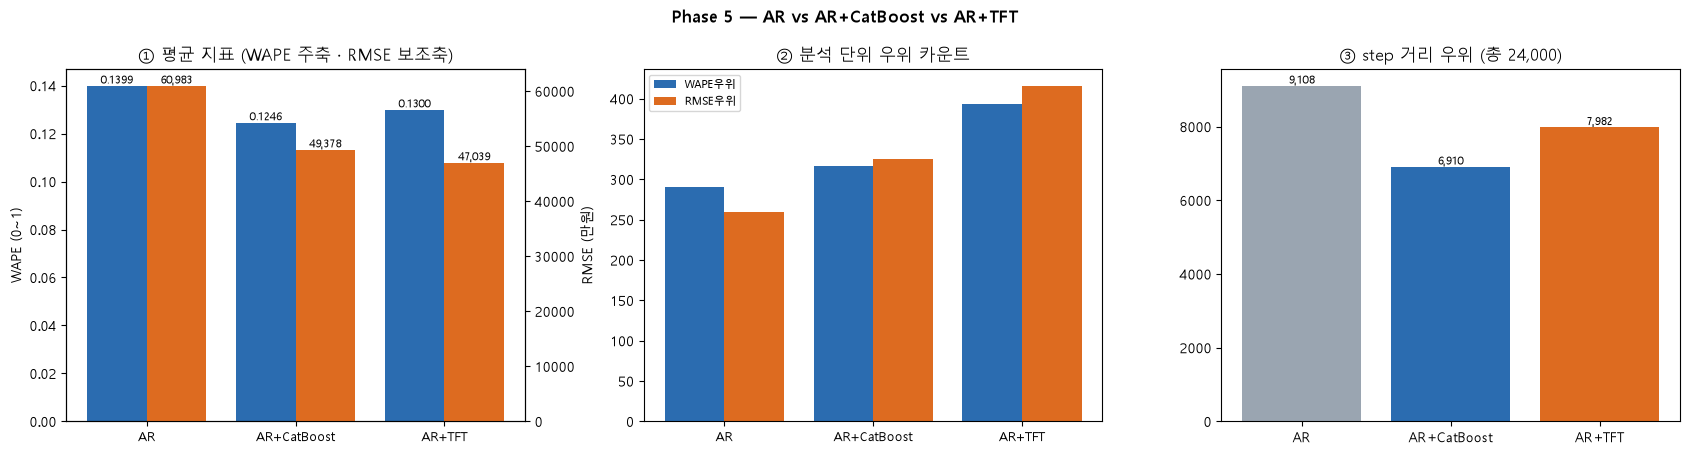


[phase5] 저장 완료: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\AR_vs_catboost_vs_tft


In [ ]:
# ===== Phase 5. AR vs AR+CatBoost vs AR+TFT 3-way 성능 평가 =====
MODELS3 = [("AR", "pred_AR"), ("AR+CatBoost", "pred_ARCB"), ("AR+TFT", "pred_ARTFT")]
names = [n for n, _ in MODELS3]

_rows = []
for v in WIN_ITEMS.values():
    for it in v:
        r = {"윈도우": it["윈도우"], "단지": it["단지"]}
        for name, key in MODELS3:
            r[f"WAPE_{name}"] = wape(it["yte"], it[key])
            r[f"RMSE_{name}"] = rmse(it["yte"], it[key])
        _rows.append(r)
cmp_df = pd.DataFrame(_rows)

# ① 평균 지표
avg3 = pd.DataFrame({
    "모델": names,
    "평균WAPE": [cmp_df[f"WAPE_{n}"].mean() for n in names],
    "평균RMSE": [cmp_df[f"RMSE_{n}"].mean() for n in names],
})
print("① 3-way 평균 점예측 지표")
print(avg3.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

# ② 분석 단위 우위 카운트(3종 중 최저)
wW = cmp_df[[f"WAPE_{n}" for n in names]].values.argmin(axis=1)
wR = cmp_df[[f"RMSE_{n}" for n in names]].values.argmin(axis=1)
win3 = pd.DataFrame({
    "모델": names,
    "WAPE우위": [int((wW == i).sum()) for i in range(3)],
    "RMSE우위": [int((wR == i).sum()) for i in range(3)],
})
n_cases = len(cmp_df)
print(f"\n② 분석 단위 우위 카운트 (총 {n_cases:,}개, 3종 중 최저)")
print(win3.to_string(index=False))

# ③ step별 거리 우위
H = CFG.HORIZON
sw3 = np.zeros(3, dtype=int)
sw_total = 0
for v in WIN_ITEMS.values():
    for it in v:
        y = it["yte"]
        dist = np.vstack([np.abs(y - it[key]) for _, key in MODELS3])
        for wi in np.argmin(dist, axis=0):
            sw3[wi] += 1
        sw_total += len(y)
swdf = pd.DataFrame({"모델": names, "step거리우위": sw3.tolist(),
                     "비율": (sw3 / max(sw_total, 1)).tolist()})
print(f"\n③ step별 거리 우위 (총 {sw_total:,} step)")
print(swdf.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# 저장 (output_final/AR_vs_catboost_vs_tft)
_CMP_DIR = log_dir("AR_vs_catboost_vs_tft")
cmp_df.to_csv(os.path.join(_CMP_DIR, "per_analysis_3way.csv"), index=False, encoding="utf-8-sig")
avg3.to_csv(os.path.join(_CMP_DIR, "avg_metrics_3way.csv"), index=False, encoding="utf-8-sig")
win3.to_csv(os.path.join(_CMP_DIR, "win_counts_3way.csv"), index=False, encoding="utf-8-sig")
swdf.to_csv(os.path.join(_CMP_DIR, "stepwise_wins_3way.csv"), index=False, encoding="utf-8-sig")

# 시각화 (① 이중축 평균 WAPE/RMSE · ② 우위 · ③ step 거리)
_cols = ["#9aa5b1", "#2b6cb0", "#dd6b20"]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
xpos = np.arange(3)
ax0 = ax[0]; ax0r = ax0.twinx()
ax0.bar(xpos - 0.2, avg3["평균WAPE"], 0.4, color="#2b6cb0", label="WAPE(주축)")
ax0r.bar(xpos + 0.2, avg3["평균RMSE"], 0.4, color="#dd6b20", label="RMSE(보조축)")
ax0.set_xticks(xpos); ax0.set_xticklabels(names, fontsize=9)
ax0.set_ylabel("WAPE (0~1)"); ax0r.set_ylabel("RMSE (만원)")
ax0.set_title("① 평균 지표 (WAPE 주축 · RMSE 보조축)")
for i, val in enumerate(avg3["평균WAPE"]):
    ax0.text(i - 0.2, val, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
for i, val in enumerate(avg3["평균RMSE"]):
    ax0r.text(i + 0.2, val, f"{val:,.0f}", ha="center", va="bottom", fontsize=8)
ax[1].bar(xpos - 0.2, win3["WAPE우위"], 0.4, color="#2b6cb0", label="WAPE우위")
ax[1].bar(xpos + 0.2, win3["RMSE우위"], 0.4, color="#dd6b20", label="RMSE우위")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(names, fontsize=9)
ax[1].set_title("② 분석 단위 우위 카운트"); ax[1].legend(fontsize=8)
ax[2].bar(names, sw3, color=_cols)
ax[2].set_title(f"③ step 거리 우위 (총 {sw_total:,})")
for i, val in enumerate(sw3):
    ax[2].text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Phase 5 — AR vs AR+CatBoost vs AR+TFT", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_CMP_DIR, "compare_3way.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase5] 저장 완료: {_CMP_DIR}")


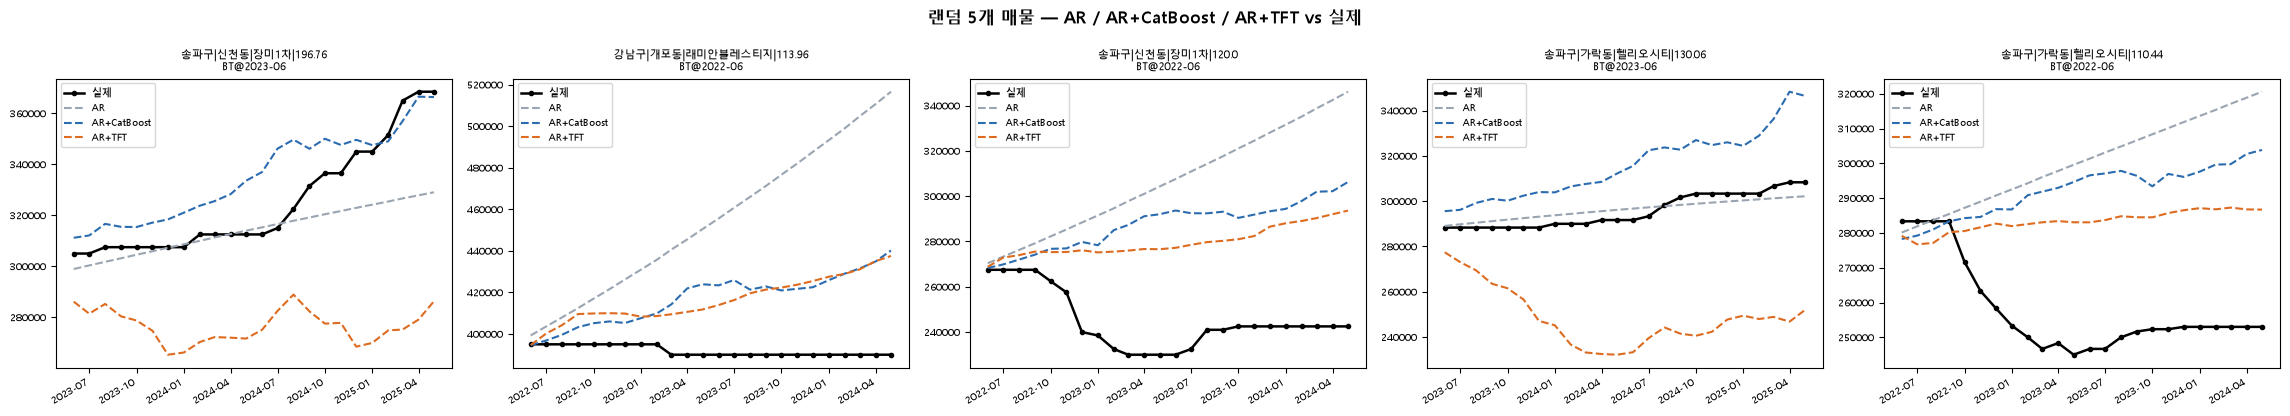

In [ ]:
# ===== Phase 5+. 랜덤 5개(윈도우×매물): AR / AR+CatBoost / AR+TFT vs 실제 =====
_all_items = [it for v in WIN_ITEMS.values() for it in v]
rng = np.random.default_rng(7)
pick = rng.choice(len(_all_items), size=min(5, len(_all_items)), replace=False)
fig, axes = plt.subplots(1, len(pick), figsize=(4.6 * len(pick), 4.2), squeeze=False)
for ax, idx in zip(axes[0], pick):
    it = _all_items[idx]
    x = it["dates"]
    ax.plot(x, it["yte"], "-o", color="black", lw=1.8, ms=3, label="실제")
    ax.plot(x, it["pred_AR"], "--", color="#9aa5b1", lw=1.5, label="AR")
    ax.plot(x, it["pred_ARCB"], "--", color="#2b6cb0", lw=1.5, label="AR+CatBoost")
    ax.plot(x, it["pred_ARTFT"], "--", color="#dd6b20", lw=1.5, label="AR+TFT")
    ax.set_title(f"{it['단지']}\n{it['윈도우']}", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    for lab in ax.get_xticklabels():
        lab.set_rotation(30); lab.set_ha("right")
fig.suptitle("랜덤 5개 매물 — AR / AR+CatBoost / AR+TFT vs 실제", fontweight="bold")
plt.tight_layout()
_CMP_DIR = log_dir("AR_vs_catboost_vs_tft")
plt.savefig(os.path.join(_CMP_DIR, "random5_3way.png"), dpi=120, bbox_inches="tight")
plt.show()


## Phase 6 — 변수 영향 해석 (CatBoost SHAP · TFT VSN)

AR h-step 잔차(`resid_target`)를 보정하는 두 모델이 **어떤 변수에 의존해 보정하는지** 분석한다.
- **CatBoost SHAP**: 윈도우별로 학습세트를 표본 추출해 `ShapValues` 계산 → 변수별 평균 |기여도|(중요도)와 평균 부호(영향 방향).
- **TFT VSN(Variable Selection Network)**: `interpret_output` 으로 encoder/decoder/static 변수 선택 가중치 추출 → 특히 **decoder_variables = 예측(미래 horizon)에 영향을 준 known reals**.
- 산출물은 모두 `output_final/shap_catboost`, `output_final/vsn_tft` 에 저장하고, 최하단 셀에서 두 관점을 종합해 "어떤 변수가 어떤 영향을 미쳤는지" 텍스트로 해석한다.


In [ ]:
# ===== Phase 6-A. CatBoost SHAP — 윈도우별 변수 기여도/방향 =====
_SHAP_DIR = log_dir("shap_catboost")
_shap_frames = []
for w in BT_WINDOWS:
    ts = WIN_TRAINSETS[w["name"]]
    if ts is None or len(ts) == 0:
        continue
    n = min(len(ts), CFG.SHAP_SAMPLE_ROWS)
    samp = ts.sample(n=n, random_state=CFG.CB_RANDOM_SEED) if len(ts) > n else ts
    X = _prep_features(samp)
    y = samp["resid_target"].values
    ci = [X.columns.get_loc(c) for c in CAT_FEATS]
    cb_w = CB_BY_WINDOW[w["name"]]
    shap = cb_w.get_feature_importance(Pool(X, y, cat_features=ci), type="ShapValues")
    shap = np.asarray(shap)[:, :-1]                       # 마지막 열(기대값) 제거
    feat_names = list(X.columns)
    imp = np.abs(shap).mean(axis=0)                       # 변수별 평균 |기여도| = 중요도
    direction = shap.mean(axis=0)                         # 변수별 평균 부호 = 영향 방향
    dfw = pd.DataFrame({"윈도우": w["name"], "변수": feat_names,
                        "중요도": imp, "방향": direction})
    dfw["부호"] = np.where(dfw["방향"] >= 0, "↑(잔차 +)", "↓(잔차 -)")
    dfw = dfw.sort_values("중요도", ascending=False).reset_index(drop=True)
    dfw.to_csv(os.path.join(_SHAP_DIR, f"shap_{w['name']}.csv"), index=False, encoding="utf-8-sig")
    _shap_frames.append(dfw)
    top = dfw.head(8)
    print(f"[shap] {w['name']} 상위 변수: " +
          ", ".join(f"{r['변수']}({r['부호']})" for _, r in top.iterrows()))

shap_all = pd.concat(_shap_frames, ignore_index=True)
# 윈도우 평균 중요도/방향 집계
shap_summary = (shap_all.groupby("변수")
                .agg(평균중요도=("중요도", "mean"), 평균방향=("방향", "mean"))
                .reset_index().sort_values("평균중요도", ascending=False).reset_index(drop=True))
shap_summary["부호"] = np.where(shap_summary["평균방향"] >= 0, "↑(잔차 상향보정)", "↓(잔차 하향보정)")
shap_summary.to_csv(os.path.join(_SHAP_DIR, "shap_summary_allwindows.csv"),
                    index=False, encoding="utf-8-sig")

# 상위 20개 막대그래프 (방향에 따라 색)
topN = shap_summary.head(20).iloc[::-1]
colors = ["#2b6cb0" if d >= 0 else "#dd6b20" for d in topN["평균방향"]]
plt.figure(figsize=(9, 7))
plt.barh(topN["변수"], topN["평균중요도"], color=colors)
plt.xlabel("평균 |SHAP| (잔차 로그 기여도)")
plt.title("CatBoost SHAP — 잔차 보정 기여 상위 20변수 (파랑=상향, 주황=하향)")
plt.tight_layout()
plt.savefig(os.path.join(_SHAP_DIR, "shap_top20.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase6-A] CatBoost SHAP 저장: {_SHAP_DIR}")
print(shap_summary.head(12).to_string(index=False, float_format=lambda x: f"{x:,.4f}"))


In [ ]:
# ===== Phase 6-B. TFT VSN — Variable Selection Network 변수 선택 가중치 =====
_VSN_DIR = log_dir("vsn_tft")


def _vsn_weights(interp, key, names):
    """interpret_output 결과에서 변수 선택 가중치 추출 → 합=1 정규화."""
    v = np.asarray(interp[key].detach().cpu().numpy(), dtype=float).ravel()
    names = list(names)
    if len(v) != len(names):                       # 길이 불일치 시 generic 이름 폴백
        names = [f"var_{i}" for i in range(len(v))]
    s = v.sum()
    return names, (v / s if s > 0 else v)


_vsn_dec_frames = []
for w in BT_WINDOWS:
    pack = TFT_BY_WINDOW.get(w["name"])
    if pack is None:
        continue
    model, tds = pack
    try:
        model.eval()
        dl = tds.to_dataloader(train=False, batch_size=CFG.TFT_BATCH, num_workers=0)
        raw = model.predict(dl, mode="raw", return_x=True)
        interp = model.interpret_output(raw.output, reduction="sum")
        for key, names in [("encoder_variables", model.encoder_variables),
                           ("decoder_variables", model.decoder_variables),
                           ("static_variables", model.static_variables)]:
            nm, wt = _vsn_weights(interp, key, names)
            dfk = pd.DataFrame({"윈도우": w["name"], "구분": key, "변수": nm, "선택가중치": wt})
            dfk = dfk.sort_values("선택가중치", ascending=False).reset_index(drop=True)
            dfk.to_csv(os.path.join(_VSN_DIR, f"vsn_{key}_{w['name']}.csv"),
                       index=False, encoding="utf-8-sig")
            if key == "decoder_variables":
                _vsn_dec_frames.append(dfk)
        top = _vsn_dec_frames[-1].head(5)
        print(f"[vsn] {w['name']} decoder 상위: " +
              ", ".join(f"{r['변수']}({r['선택가중치']:.2f})" for _, r in top.iterrows()))
    except Exception as e:
        print(f"[vsn] {w['name']} 추출 실패: {type(e).__name__}: {e}")

if _vsn_dec_frames:
    vsn_dec = pd.concat(_vsn_dec_frames, ignore_index=True)
    vsn_dec_summary = (vsn_dec.groupby("변수")["선택가중치"].mean()
                       .reset_index().sort_values("선택가중치", ascending=False).reset_index(drop=True))
    vsn_dec_summary.to_csv(os.path.join(_VSN_DIR, "vsn_decoder_summary_allwindows.csv"),
                           index=False, encoding="utf-8-sig")
    top = vsn_dec_summary.iloc[::-1]
    plt.figure(figsize=(8, 4.8))
    plt.barh(top["변수"], top["선택가중치"], color="#dd6b20")
    plt.xlabel("평균 VSN 선택 가중치 (decoder = 예측에 영향)")
    plt.title("TFT VSN — 미래 horizon 예측에 영향을 준 known reals")
    plt.tight_layout()
    plt.savefig(os.path.join(_VSN_DIR, "vsn_decoder_top.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n[phase6-B] TFT VSN 저장: {_VSN_DIR}")
    print(vsn_dec_summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))
else:
    vsn_dec_summary = pd.DataFrame(columns=["변수", "선택가중치"])
    print("[phase6-B] VSN 추출 결과 없음")


In [ ]:
# ===== Phase 6-C. 종합 해석 — 어떤 변수가 어떤 영향을 미쳤는가 =====
# CatBoost SHAP(세부 변수·방향)와 TFT VSN(known reals 선택)을 나란히 비교·서술한다.
_ANA_DIR = log_dir("explainability_summary")

print("=" * 78)
print("■ 종합 변수 영향 해석  (AR 잔차 보정 관점)")
print("=" * 78)

# ── 1) CatBoost SHAP: 상위 기여 변수와 영향 방향 ──
print("\n[1] CatBoost — 잔차 보정에 가장 크게 기여한 변수 (평균 |SHAP|)")
cb_top = shap_summary.head(10).copy()
for rank, (_, r) in enumerate(cb_top.iterrows(), 1):
    eff = "예측을 상향(가격↑) 보정" if r["평균방향"] >= 0 else "예측을 하향(가격↓) 보정"
    print(f"   {rank:2d}. {r['변수']:<28s} 중요도 {r['평균중요도']:.4f} → 평균적으로 {eff}")

# ── 2) TFT VSN: 미래 예측(decoder)에 영향을 준 known reals ──
print("\n[2] TFT VSN — 미래 horizon 예측에 영향을 준 known reals (decoder 선택 가중치)")
if len(vsn_dec_summary):
    for rank, (_, r) in enumerate(vsn_dec_summary.head(10).iterrows(), 1):
        print(f"   {rank:2d}. {r['변수']:<20s} 선택가중치 {r['선택가중치']:.4f}")
else:
    print("   (VSN 결과 없음)")

# ── 3) 두 모델 공통 시사점 ──
print("\n[3] 종합 시사점")
_cb_origin = cb_top[cb_top["변수"].isin(["base_drift", "origin_last", "origin_mom3",
                                          "origin_mom6", "origin_mom12", "h_step"])]
if len(_cb_origin):
    print("   · 원점 추세(base_drift/origin_*)·예측구간(h_step)이 SHAP 상위에 → "
          "AR 점예측의 모멘텀/구간 길이가 잔차 보정의 핵심.")
_cb_macro = cb_top[cb_top["변수"].str.startswith("depth")]
if len(_cb_macro):
    print("   · 거시/지역 depth 변수(" + ", ".join(_cb_macro["변수"].head(3)) +
          " 등)가 상위 → 매물 외부 시장환경이 잔차에 유의미.")
_cb_static = cb_top[cb_top["변수"].str.startswith("Static__")]
if len(_cb_static):
    print("   · 정적 단지속성(" + ", ".join(_cb_static["변수"].head(3)) +
          " 등) → 단지 고유특성이 보정 방향을 좌우.")
if len(vsn_dec_summary):
    _vd = vsn_dec_summary.iloc[0]
    print(f"   · TFT는 decoder에서 '{_vd['변수']}'(가중치 {_vd['선택가중치']:.2f})를 가장 비중 있게 선택 → "
          "TFT의 미래 보정도 동일 신호에 의존.")

# 종합표 저장
merged = shap_summary.rename(columns={"평균중요도": "CatBoost_중요도", "평균방향": "CatBoost_방향"})
merged.to_csv(os.path.join(_ANA_DIR, "explainability_catboost_shap.csv"),
              index=False, encoding="utf-8-sig")
if len(vsn_dec_summary):
    vsn_dec_summary.rename(columns={"선택가중치": "TFT_decoder_가중치"}).to_csv(
        os.path.join(_ANA_DIR, "explainability_tft_vsn.csv"), index=False, encoding="utf-8-sig")
print(f"\n[phase6-C] 종합 해석 저장: {_ANA_DIR}")
print("=" * 78)
